# Decision Tree Classifier (explicit if-else rules)
**Data:** Temporally split parquets (`train_t03`, `val_t03`, `test_t03`)  
**Target:** `Results` --> `1 = Fail`, `0 = Pass`

### Modelling Flow
1. Load temporally-split parquets (train_t03, val_t03, test_t03)
2. Baseline Decision Tree (default hyperparameters)
   - Establishes a lower-bound reference score
3. Hyperparameter Tuning via RandomizedSearchCV + PredefinedSplit
   - Randomly samples 80 combinations from the search space
   - PredefinedSplit enforces our temporal split during search (no shuffling)
   - Scored on F1-weighted to account for class imbalance (70% Pass / 30% Fail)
4. Refit best model on train only
   - Best params applied to a clean model trained on past data only
5. Evaluate on Val → Test
   - Val: used during development to monitor performance
   - Test: final honest evaluation, touched only once
6. Interpret results
   - Confusion matrix, feature importances, tree visualization

### Class Imbalance Handling
The training set is imbalanced (**70.5% Pass, 29.5% Fail**). The tuner selected
`class_weight='balanced'`, which internally re-weights each class inversely proportional
to its frequency — making the model pay more attention to the minority Fail class
instead of defaulting to always predicting Pass.

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import RandomizedSearchCV, PredefinedSplit
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, accuracy_score,
    f1_score, precision_score, recall_score,
    matthews_corrcoef, balanced_accuracy_score,
    average_precision_score, brier_score_loss, ConfusionMatrixDisplay
)
from scipy.stats import randint

import warnings
warnings.filterwarnings('ignore')

import joblib
from pathlib import Path

RANDOM_STATE = 42   # a fixed seed so results are reproducible every run
TARGET = 'Results'  # 1 = Fail, 0 = Pass

## 2. Load Data

In [2]:
BASE = '../../data/transformed'

train = pd.read_parquet(f'{BASE}/train_t03.parquet')
val   = pd.read_parquet(f'{BASE}/val_t03.parquet')
test  = pd.read_parquet(f'{BASE}/test_t03.parquet')

print(f'Train : {train.shape}')
print(f'Val   : {val.shape}')
print(f'Test  : {test.shape}')

Train : (109693, 13)
Val   : (27483, 13)
Test  : (34294, 13)


## 3. Prepare Features & Target

In [3]:
def prepare(df, target=TARGET):
    """Separates features from target: split into X: features, y: target & cast bool columns to int. """
    X = df.drop(columns=[target]).copy() # features
    
    # has_prior_inspection is bool — cast to int for sklearn
    bool_cols = X.select_dtypes(include='bool').columns
    X[bool_cols] = X[bool_cols].astype(int)
    
    y = df[target] # target (Results: 1=Fail, 0=Pass)
    return X, y

X_train, y_train = prepare(train)
X_val,   y_val   = prepare(val)
X_test,  y_test  = prepare(test)

print('Features:', X_train.columns.tolist())
print(f'\nClass distribution in train (1=Fail, 0=Pass):')
print(y_train.value_counts(normalize=True).round(3))

Features: ['Risk', 'has_prior_inspection', 'violation_count', 'days_to_license_expiry', 'license_expiry_missing', 'days_since_last_inspection', 'prev_inspection_result', 'fail_rate_last_3', 'inspection_type_encoded', 'facility_type_encoded', 'is_revoked', 'application_type_encoded']

Class distribution in train (1=Fail, 0=Pass):
Results
0    0.705
1    0.295
Name: proportion, dtype: float64


## 4. Baseline Decision Tree
(Default hyperparameters - gives a reference point before tuning)

Trains a tree with zero tuning - completely default settings.

This acts as a reference point -->
"how well does a naive tree do before we put any effort in?"

In [4]:
baseline = DecisionTreeClassifier(random_state=RANDOM_STATE)
baseline.fit(X_train, y_train)

val_preds_base = baseline.predict(X_val)

print('=== Baseline (default hyperparameters) — Validation Set ===')
print(classification_report(y_val, val_preds_base, target_names=['Pass (0)', 'Fail (1)']))
print(f'ROC-AUC : {roc_auc_score(y_val, baseline.predict_proba(X_val)[:, 1]):.4f}')
print(f'Tree depth: {baseline.get_depth()}')

=== Baseline (default hyperparameters) — Validation Set ===
              precision    recall  f1-score   support

    Pass (0)       0.80      0.84      0.82     19211
    Fail (1)       0.58      0.51      0.54      8272

    accuracy                           0.74     27483
   macro avg       0.69      0.67      0.68     27483
weighted avg       0.73      0.74      0.74     27483

ROC-AUC : 0.6744
Tree depth: 60


## 5. Hyperparameter Tuning - RandomizedSearchCV

We use **`PredefinedSplit`** instead of regular k-fold (cross-validation) so the search always trains on
past data and evaluates on future data - consistent with our temporal split strategy.

- `split_index = -1` --> training row  
- `split_index =  0` --> validation row (fold 0)

In [5]:
X_search = pd.concat([X_train, X_val], axis=0).reset_index(drop=True)
y_search = pd.concat([y_train, y_val], axis=0).reset_index(drop=True)

split_index = [-1] * len(X_train) + [0] * len(X_val)
ps = PredefinedSplit(test_fold=split_index)

param_dist = {
    'criterion'        : ['gini', 'entropy'],
    'max_depth'        : randint(3, 20),
    'min_samples_split': randint(2, 50),
    'min_samples_leaf' : randint(1, 30),
    'max_features'     : [None, 'sqrt', 'log2'],
    'class_weight'     : [None, 'balanced'],
}

search = RandomizedSearchCV(
    estimator=DecisionTreeClassifier(random_state=RANDOM_STATE),
    param_distributions=param_dist,
    n_iter=80,
    scoring='f1_weighted',
    cv=ps,
    n_jobs=-1,
    verbose=1,
    random_state=RANDOM_STATE,
    refit=False,
)

search.fit(X_search, y_search)

print('\nBest params found:')
for k, v in search.best_params_.items():
    print(f'  {k}: {v}')
print(f'\nBest val F1 (weighted): {search.best_score_:.4f}')

Fitting 1 folds for each of 80 candidates, totalling 80 fits

Best params found:
  class_weight: None
  criterion: entropy
  max_depth: 3
  max_features: log2
  min_samples_leaf: 1
  min_samples_split: 6

Best val F1 (weighted): 0.8006


## 6. Refit Best Model on Train Only

In [6]:
best_params = search.best_params_

best_dt = DecisionTreeClassifier(**best_params, random_state=RANDOM_STATE)
best_dt.fit(X_train, y_train)

print('Model fitted on train set only.')
print(f'Tree depth : {best_dt.get_depth()}')
print(f'Leaf nodes : {best_dt.get_n_leaves()}')

Model fitted on train set only.
Tree depth : 3
Leaf nodes : 8


## 7. Evaluation

In [7]:
def evaluate(model, X, y, split_name):
    y_pred       = model.predict(X)
    y_pred_proba = model.predict_proba(X)[:, 1]
    cm           = confusion_matrix(y, y_pred)
    tn, fp, fn, tp = cm.ravel()

    # --- derived rates ---
    fnr = fn / (fn + tp)
    fpr = fp / (fp + tn)
    tpr = tp / (tp + fn)
    tnr = tn / (tn + fp)

    # --- metrics ---
    roc_auc       = roc_auc_score(y, y_pred_proba)
    pr_auc        = average_precision_score(y, y_pred_proba)
    brier         = brier_score_loss(y, y_pred_proba)
    mcc           = matthews_corrcoef(y, y_pred)
    bal_acc       = balanced_accuracy_score(y, y_pred)
    f1_fail       = f1_score(y, y_pred, pos_label=1, zero_division=0)
    f1_pass       = f1_score(y, y_pred, pos_label=0, zero_division=0)
    f1_weighted   = f1_score(y, y_pred, average='weighted', zero_division=0)
    prec_fail     = precision_score(y, y_pred, pos_label=1, zero_division=0)
    recall_fail   = recall_score(y, y_pred, pos_label=1, zero_division=0)

    print(f'=== {split_name} ===')
    print(classification_report(y, y_pred, target_names=['Pass', 'Fail']))

    print('── Key Rates ──')
    print(f'  Sensitivity (Recall Fail):           {tpr:.4f}')
    print(f'  Specificity (Recall Pass):           {tnr:.4f}')
    print(f'  False Negative Rate (missed fails):  {fnr:.4f}')
    print(f'  False Positive Rate (wasted insp.):  {fpr:.4f}')

    print('── Model Quality ──')
    print(f'  ROC-AUC:                             {roc_auc:.4f}')
    print(f'  PR-AUC:                              {pr_auc:.4f}')
    print(f'  Brier Score (lower = better):        {brier:.4f}')
    print(f'  MCC:                                 {mcc:.4f}')
    print(f'  Balanced Accuracy:                   {bal_acc:.4f}')

    print('── Per Class ──')
    print(f'  Precision — Fail:                    {prec_fail:.4f}')
    print(f'  Recall    — Fail:                    {recall_fail:.4f}')
    print(f'  F1        — Fail:                    {f1_fail:.4f}')
    print(f'  F1        — Pass:                    {f1_pass:.4f}')
    print(f'  F1        — Weighted:                {f1_weighted:.4f}')
    print()

    metrics = {
        # counts
        'tp'                 : int(tp),
        'tn'                 : int(tn),
        'fp'                 : int(fp),
        'fn'                 : int(fn),
        # rates
        'sensitivity'        : tpr,
        'specificity'        : tnr,
        'false_negative_rate': fnr,
        'false_positive_rate': fpr,
        # model quality
        'accuracy'           : accuracy_score(y, y_pred),
        'balanced_accuracy'  : bal_acc,
        'roc_auc'            : roc_auc,
        'pr_auc'             : pr_auc,
        'brier_score'        : brier,
        'mcc'                : mcc,
        # per class
        'precision_fail'     : prec_fail,
        'recall_fail'        : recall_fail,
        'f1_fail'            : f1_fail,
        'f1_pass'            : f1_pass,
        'f1_weighted'        : f1_weighted,
    }

    return y_pred_proba, cm, metrics

train_probas, train_cm, train_metrics = evaluate(best_dt, X_train, y_train, 'Train')
val_probas,   val_cm,   val_metrics   = evaluate(best_dt, X_val,   y_val,   'Validation')
test_probas,  test_cm,  test_metrics  = evaluate(best_dt, X_test,  y_test,  'Test')

=== Train ===
              precision    recall  f1-score   support

        Pass       0.83      0.86      0.85     77306
        Fail       0.64      0.57      0.60     32387

    accuracy                           0.78    109693
   macro avg       0.73      0.72      0.72    109693
weighted avg       0.77      0.78      0.77    109693

── Key Rates ──
  Sensitivity (Recall Fail):           0.5729
  Specificity (Recall Pass):           0.8626
  False Negative Rate (missed fails):  0.4271
  False Positive Rate (wasted insp.):  0.1374
── Model Quality ──
  ROC-AUC:                             0.7844
  PR-AUC:                              0.5593
  Brier Score (lower = better):        0.1589
  MCC:                                 0.4496
  Balanced Accuracy:                   0.7177
── Per Class ──
  Precision — Fail:                    0.6359
  Recall    — Fail:                    0.5729
  F1        — Fail:                    0.6028
  F1        — Pass:                    0.8450
  F1     

### 7.3 Overfitting Check — Train / Val / Test Comparison

| Metric | What it measures | When to use |
|---|---|---|
| **Accuracy** | % of all predictions correct | Only reliable when classes are balanced |
| **F1 (weighted)** | Harmonic mean of precision & recall, weighted by class size | Good overall summary with imbalance |
| **F1 — Fail (1)** | How well we specifically detect failing restaurants | Most important for the business problem |
| **ROC-AUC** | Model's ability to rank Fail above Pass across all thresholds | Best single metric for comparing models |

> For this project, **F1-Fail and ROC-AUC are the most meaningful metrics** — missing a
> truly failing restaurant (False Negative) is more costly than a false alarm.

### 7.4 Confusion Matrices

|                 | Predicted Pass                     | Predicted Fail                    |
|-----------------|------------------------------------|-----------------------------------|
| **Actual Pass** | True Negative (correctly cleared)  | False Positive (false alarm)      |
| **Actual Fail** | False Negative (missed violation)  | True Positive (correctly caught)  |

- **True Positive (bottom-right):** Failing restaurant correctly flagged (inspector dispatched)
- **False Negative (bottom-left):** Failing restaurant predicted safe  **(most dangerous error)**
- **False Positive (top-right):** Safe restaurant flagged (wasted inspector trip)
- **True Negative (top-left):** Safe restaurant correctly cleared

> On the test set, the model catches **13,433 out of 16,678** truly failing restaurants
> (80.5% recall on Fail class). It misses **3,245** — these are the high-priority errors
> to minimize in future model iterations.

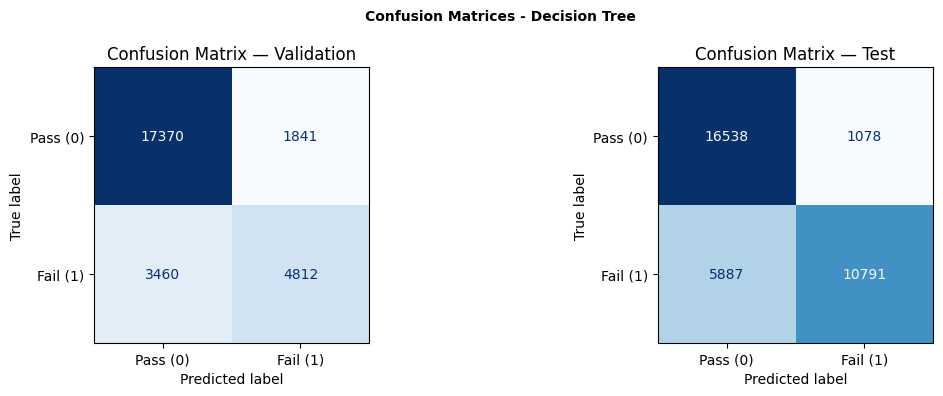

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, (cm, title) in zip(axes, [
    (val_cm,  'Validation'),
    (test_cm, 'Test'),
]):
    disp = ConfusionMatrixDisplay(cm, display_labels=['Pass (0)', 'Fail (1)'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'Confusion Matrix — {title}')

plt.suptitle("Confusion Matrices - Decision Tree", fontsize=10, fontweight="bold")
plt.tight_layout()
plt.savefig('confusion_matrices_dt.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Feature Importance

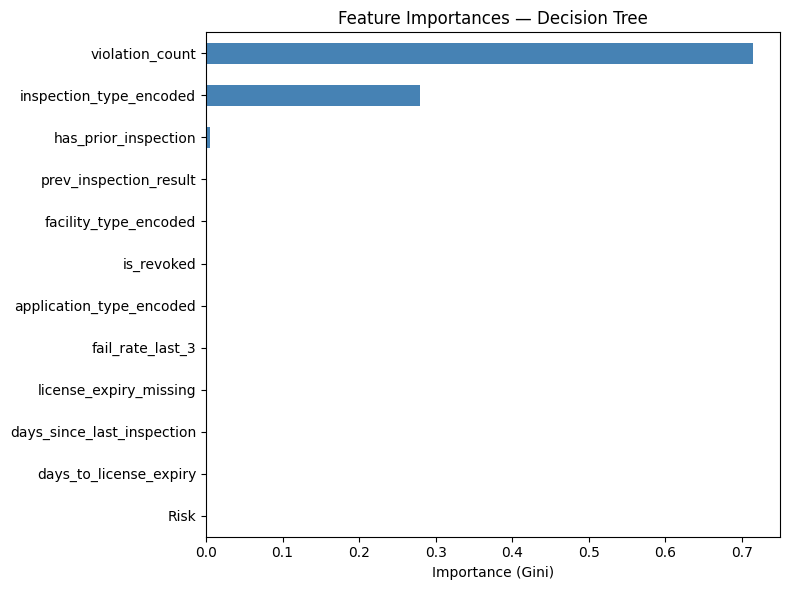


Top 5 most important features:
violation_count            0.714188
inspection_type_encoded    0.279772
has_prior_inspection       0.005201
prev_inspection_result     0.000839
license_expiry_missing     0.000000
dtype: float64


In [9]:
importances = pd.Series(
    best_dt.feature_importances_,
    index=X_train.columns
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 6))
importances.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Feature Importances — Decision Tree')
ax.set_xlabel('Importance (Gini)')
plt.tight_layout()
plt.savefig('feature_importance_dt.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nTop 5 most important features:')
print(importances.sort_values(ascending=False).head())

## 9. Visualize the Tree (Top 3 Levels)
Capped at `max_depth=3` for readability

Read top-down. Each node shows:
- **Condition**: the question asked (e.g., `violation_count <= 3.5`)
- **Entropy**: how mixed the classes are at this node (0 = pure, 1 = perfectly mixed)
- **Samples**: how many training rows reach this node
- **Value**: `[Pass count, Fail count]` at this node
- **Class**: the majority class (what would be predicted if we stopped here)

Orange nodes --> majority Pass. Blue nodes --> majority Fail.

The root split on `days_since_last_inspection <= 35.5` means the single most informative
first question is: *"Has this restaurant been inspected in the last 35 days?"*

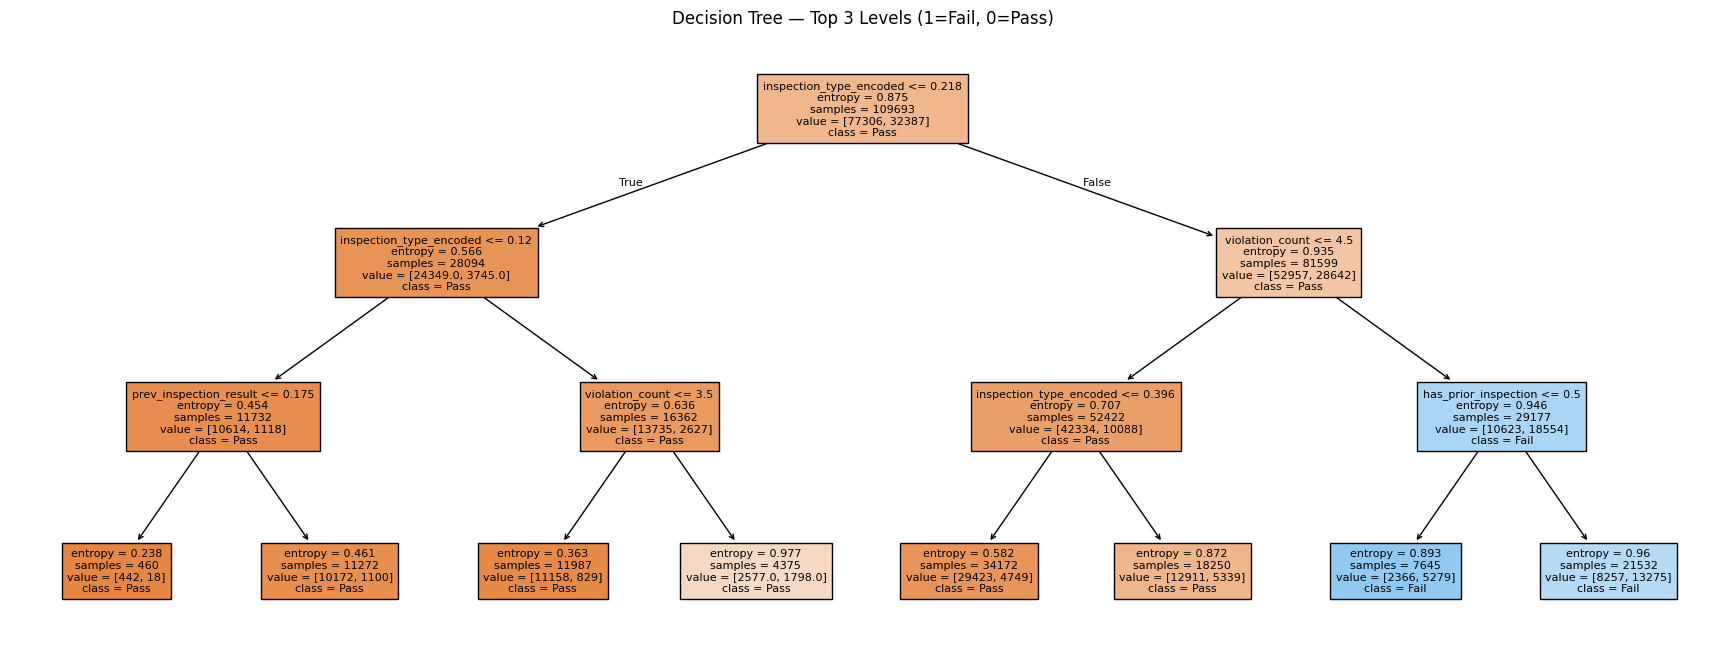

In [10]:
fig, ax = plt.subplots(figsize=(22, 8))
plot_tree(
    best_dt,
    feature_names=X_train.columns.tolist(),
    class_names=['Pass', 'Fail'],
    filled=True,
    max_depth=3,
    fontsize=8,
    ax=ax,
)
plt.title('Decision Tree — Top 3 Levels (1=Fail, 0=Pass)')
plt.savefig('dt_tree_plot.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Final Summary

In [11]:
print('=== Decision Tree — Final Summary ===')
print(f'Best criterion  : {best_params["criterion"]}')
print(f'Best max_depth  : {best_params["max_depth"]}')
print(f'Tree depth      : {best_dt.get_depth()}')
print(f'Leaf nodes      : {best_dt.get_n_leaves()}')
print()

summary = pd.DataFrame({
    'Split'              : ['Train', 'Val', 'Test'],
    'Accuracy'           : [train_metrics['accuracy'],            val_metrics['accuracy'],            test_metrics['accuracy']],
    'Balanced Accuracy'  : [train_metrics['balanced_accuracy'],   val_metrics['balanced_accuracy'],   test_metrics['balanced_accuracy']],
    'F1 (weighted)'      : [train_metrics['f1_weighted'],         val_metrics['f1_weighted'],         test_metrics['f1_weighted']],
    'F1 — Fail'          : [train_metrics['f1_fail'],             val_metrics['f1_fail'],             test_metrics['f1_fail']],
    'ROC-AUC'            : [train_metrics['roc_auc'],             val_metrics['roc_auc'],             test_metrics['roc_auc']],
    'PR-AUC'             : [train_metrics['pr_auc'],              val_metrics['pr_auc'],              test_metrics['pr_auc']],
    'MCC'                : [train_metrics['mcc'],                 val_metrics['mcc'],                 test_metrics['mcc']],
    'FNR (missed fails)' : [train_metrics['false_negative_rate'], val_metrics['false_negative_rate'], test_metrics['false_negative_rate']],
    'Catch Rate'         : [train_metrics['sensitivity'],         val_metrics['sensitivity'],         test_metrics['sensitivity']],
}).set_index('Split').round(4)

display(summary)

=== Decision Tree — Final Summary ===
Best criterion  : entropy
Best max_depth  : 3
Tree depth      : 3
Leaf nodes      : 8



,Accuracy,Balanced Accuracy,F1 (weighted),F1 — Fail,ROC-AUC,PR-AUC,MCC,FNR (missed fails),Catch Rate
Split,,,,,,,,,
Train,0.7771,0.7177,0.7735,0.6028,0.7844,0.5593,0.4496,0.4271,0.5729
Val,0.8071,0.7429,0.8006,0.6448,0.7922,0.6012,0.5203,0.4183,0.5817
Test,0.7969,0.7929,0.7920,0.7560,0.8315,0.8183,0.6155,0.3530,0.6470


## 11. Save Results

In [12]:
models_dir = Path.cwd().parent.parent / 'models'
models_dir.mkdir(exist_ok=True)

joblib.dump(best_dt, models_dir / 'decision_tree.pkl')
print(f'Model saved to {models_dir / "decision_tree.pkl"}')

Model saved to /home/engomar/Desktop/Year_04_Spring_2026/Data_Science/CMPS344_Project/Food-Inspection/models/decision_tree.pkl


In [13]:
import mlflow
import mlflow.sklearn

mlflow.set_tracking_uri("../../mlruns")
mlflow.set_experiment("food-inspection-classification")

with mlflow.start_run(run_name="decision-tree"):

    # --- hyperparameters ---
    mlflow.log_params(best_params)
    mlflow.log_param("random_state", RANDOM_STATE)

    # --- standard metrics ---
    mlflow.log_metric("test_accuracy",          test_metrics['accuracy'])
    mlflow.log_metric("test_balanced_accuracy", test_metrics['balanced_accuracy'])
    mlflow.log_metric("test_f1_weighted",       test_metrics['f1_weighted'])
    mlflow.log_metric("test_f1_fail",           test_metrics['f1_fail'])
    mlflow.log_metric("test_f1_pass",           test_metrics['f1_pass'])
    mlflow.log_metric("test_mcc",               test_metrics['mcc'])
    mlflow.log_metric("test_pr_auc",            test_metrics['pr_auc'])
    mlflow.log_metric("test_brier_score",       test_metrics['brier_score'])
    mlflow.log_metric("test_precision_fail",    test_metrics['precision_fail'])
    mlflow.log_metric("test_recall_fail",       test_metrics['recall_fail'])

    # --- business metrics ---
    mlflow.log_metric("test_false_negative_rate", test_metrics['false_negative_rate'])
    mlflow.log_metric("test_false_positive_rate", test_metrics['false_positive_rate'])
    mlflow.log_metric("test_failing_catch_rate",  test_metrics['sensitivity'])

    # --- val + test roc ---
    mlflow.log_metric("val_roc_auc",  val_metrics['roc_auc'])
    mlflow.log_metric("test_roc_auc", test_metrics['roc_auc'])

    # --- model artifact ---
    mlflow.sklearn.log_model(best_dt, artifact_path="model")

    # --- plot artifacts ---
    mlflow.log_artifact("confusion_matrices_dt.png")
    mlflow.log_artifact("feature_importance_dt.png")
    mlflow.log_artifact("dt_tree_plot.png")

    run_id = mlflow.active_run().info.run_id
    print(f"Run logged. ID: {run_id}")

2026/05/05 00:02:00 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/05 00:02:01 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Run logged. ID: fd37bb797eb7437180f25973dbc85163
